# Práctica: Comparación de modelos de regresión

**Materia:** Tópicos de Big Data
**Tema:** Introducción al aprendizaje supervisado mediante modelos de regresión
**Herramientas:** Python · Jupyter Notebook · Pandas · NumPy · Matplotlib · Scikit-learn

---

## 1. Objetivo

Construir diferentes modelos de aprendizaje supervisado para realizar **proyecciones del número de nacimientos y defunciones** de un país, utilizando datos históricos.

Durante la práctica se implementarán y compararán visualmente tres modelos:

1. Regresión lineal
2. Regresión polinomial
3. Random Forest Regressor

Al finalizar, podrás observar cómo **diferentes modelos generan predicciones diferentes utilizando exactamente los mismos datos**.

> **Nota:** En esta práctica **no** se realizará todavía la evaluación formal de los modelos. La evaluación mediante métricas se realizará en la siguiente sesión.

---

## 2. Dataset

Utilizaremos información de **Our World in Data (OWID)** sobre nacimientos y defunciones, que incluye datos históricos y proyecciones hasta el año 2100.

Fuente: *Our World in Data – Births and deaths projected to 2100* (basado en las estimaciones y proyecciones de la ONU).

El dataset contiene información por **país (o región) y año**.

# PARTE 1. Importar las bibliotecas

En esta práctica utilizaremos:

* **Pandas** para trabajar con el dataset.
* **NumPy** para trabajar con arreglos y preparar datos.
* **Matplotlib** para visualizar los datos y las predicciones.
* **Scikit-learn** para construir los modelos de Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar el dataset

## 3. Cargar los datos

Leemos el archivo CSV directamente desde la página de OWID.

> **Si no hay internet (o la descarga falla):** descarga el CSV desde la URL de la celda siguiente, guárdalo en la misma carpeta que este notebook con el nombre `births-and-deaths-projected-to-2100.csv` y vuelve a ejecutar la celda. El código lo detecta automáticamente.

In [3]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

df.head()

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


## 4. Explorar el dataset

Observemos la estructura del `DataFrame`.

In [4]:
print("Dimensiones (filas, columnas):", df.shape)
print()
print("Columnas:")
for columna in df.columns:
    print("  -", columna)

Dimensiones (filas, columnas): (39562, 7)

Columnas:
  - entity
  - code
  - year
  - deaths__sex_all__age_all__variant_estimates
  - deaths__sex_all__age_all__variant_medium__projected
  - births__sex_all__age_all__variant_estimates
  - births__sex_all__age_all__variant_medium__projected


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39562 entries, 0 to 39561
Data columns (total 7 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   entity                                               39562 non-null  str    
 1   code                                                 38354 non-null  str    
 2   year                                                 39562 non-null  int64  
 3   deaths__sex_all__age_all__variant_estimates          18944 non-null  float64
 4   deaths__sex_all__age_all__variant_medium__projected  19712 non-null  float64
 5   births__sex_all__age_all__variant_estimates          19166 non-null  float64
 6   births__sex_all__age_all__variant_medium__projected  19943 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 2.1 MB


In [6]:
df.head(10)

,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN
5,Afghanistan,AFG,1955,286725.0,NaN,417650.0,NaN
6,Afghanistan,AFG,1956,286654.0,NaN,425071.0,NaN
7,Afghanistan,AFG,1957,286114.0,NaN,432044.0,NaN
8,Afghanistan,AFG,1958,285911.0,NaN,439867.0,NaN
9,Afghanistan,AFG,1959,285500.0,NaN,447510.0,NaN


Revisemos las entidades disponibles:

In [7]:
print("Número de entidades:", df["entity"].nunique())
df["entity"].unique()

Número de entidades: 262


<StringArray>
[      'Afghanistan',            'Africa',       'Africa (UN)',
           'Albania',           'Algeria',    'American Samoa',
     'Americas (UN)',           'Andorra',            'Angola',
          'Anguilla',
 ...
           'Vanuatu',           'Vatican',         'Venezuela',
           'Vietnam', 'Wallis and Futuna',    'Western Sahara',
             'World',             'Yemen',            'Zambia',
          'Zimbabwe']
Length: 262, dtype: str

### Pregunta

**¿Cuál es la unidad de observación de cada fila del dataset?**

*La unidad de observación es una entidad (país o región) en un año específico.*



### ANÁLISIS DEMOGRÁFICO - MÉXICO (1980 y 2000)

In [60]:
df = df.rename(columns={
    "entity": "Entity",
    "year": "Year",
    "births_sex_all_age_all_variant_estimates": "births_estimates",
    "births_sex_all_age_all_variant_medium_projected": "births_projected",
    "deaths_sex_all_age_all_variant_estimates": "deaths_estimates",
    "deaths_sex_all_age_all_variant_medium_projected": "deaths_projected"
})

df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])


df_mexico = df[df["Entity"] == "Mexico"]

In [61]:
def proyectar_y_graficar(df_pais, anio_inicio, variable_objetivo="births"):
    df_historico = df_pais[(df_pais["Year"] >= anio_inicio) & (df_pais["Year"] <= 2023)]
    df_proyectado = df_pais[df_pais["Year"] > 2023]
    
    X = df_historico[["Year"]]
    y = df_historico[variable_objetivo]
    
    anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
    X_futuro = pd.DataFrame(anios_futuros, columns=["Year"])
    
    # Modelos
    mod_lineal = LinearRegression().fit(X, y)
    pred_lineal = mod_lineal.predict(X_futuro)
    
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(X)
    mod_poly = LinearRegression().fit(X_poly, y)
    pred_poly = mod_poly.predict(poly.transform(X_futuro))
    
    mod_rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)
    pred_rf = mod_rf.predict(X_futuro)
    
    # Graficar
    plt.figure(figsize=(14, 7))
    plt.scatter(df_historico["Year"], df_historico[variable_objetivo], 
                label=f"Datos históricos (Desde {anio_inicio})", alpha=0.5)
    
    plt.plot(df_proyectado["Year"], df_proyectado[variable_objetivo], 
             color="black", linewidth=2.5, label="Proyección OWID")
    plt.plot(anios_futuros.flatten(), pred_lineal, color="tab:orange", label="Regresión lineal")
    plt.plot(anios_futuros.flatten(), pred_poly, color="tab:green", label="Regresión polinomial")
    plt.plot(anios_futuros.flatten(), pred_rf, color="tab:red", label="Random Forest")
    
    titulo_var = "Nacimientos" if variable_objetivo == "births" else "Defunciones"
    plt.title(f"Proyecciones de {titulo_var} en México (Entrenamiento desde {anio_inicio})")
    plt.xlabel("Año")
    plt.ylabel(titulo_var)
    plt.ticklabel_format(style="plain", axis="y", useOffset=False)
    plt.legend()
    plt.grid()
    plt.show()

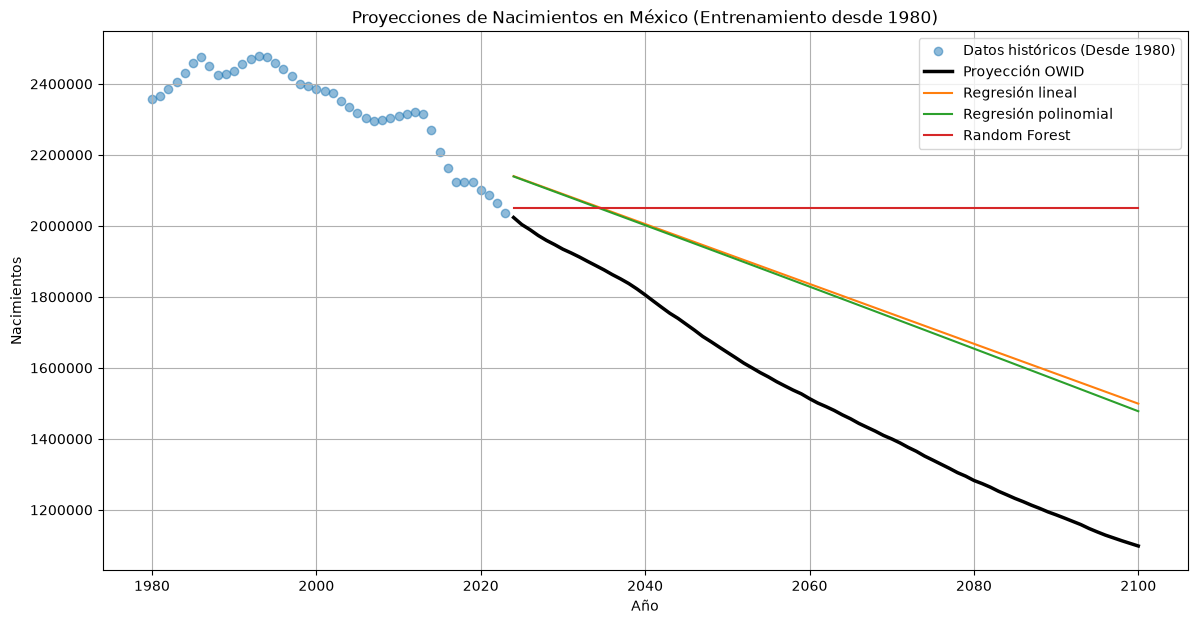

In [62]:
proyectar_y_graficar(df_mexico, anio_inicio=1980, variable_objetivo="births")

### observaciónes

*Datos históricos (Puntos azules): Al omitir los datos previos a 1980, el patrón principal que asimilan los algoritmos es una caída sostenida después de un ligero pico en los años 90.*

*Regresión Lineal (Naranja) y Polinomial (Verde): Al aprender exclusivamente de esta etapa de declive, ambas trazan trayectorias descendentes casi idénticas hacia el futuro. Sin embargo, su pendiente resulta conservadora y predicen una cantidad de nacimientos considerablemente mayor a la proyección oficial para el final del siglo.*

*Random Forest (Rojo): Mantiene su limitación estructural; al ser incapaz de extrapolar valores temporales inéditos, se congela en una línea recta horizontal repitiendo el último dato registrado en 2023.*

*Proyección OWID (Negro): Pronostica una caída mucho más acelerada y profunda que los tres modelos matemáticos, estimando que los nacimientos se reducirán a cerca de 1.1 millones para el año 2100.*

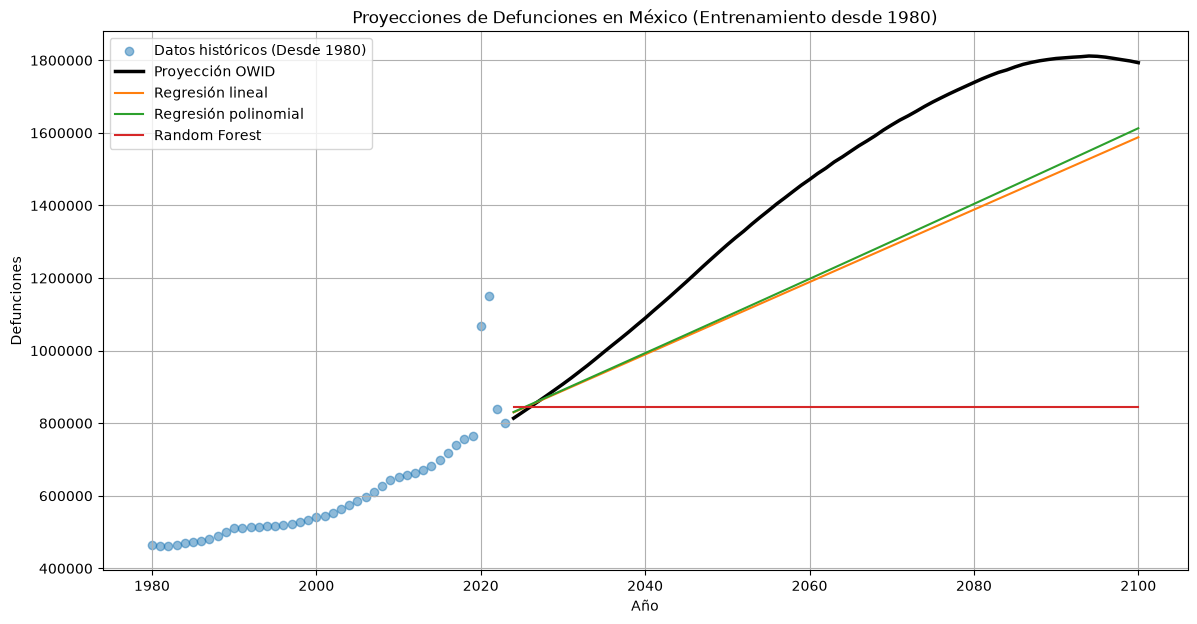

In [63]:
proyectar_y_graficar(df_mexico, anio_inicio=1980, variable_objetivo="deaths")

### observaciónes

*Anomalía histórica (Puntos azules): La tendencia de crecimiento constante se ve interrumpida por un pico extremo y atípico alrededor de 2020, lo cual distorsiona el aprendizaje de los algoritmos básicos.*

*Subestimación del crecimiento (Naranja y Verde): La Regresión Lineal y la Polinomial trazan trayectorias ascendentes casi idénticas, pero proyectan una pendiente conservadora que se queda muy por debajo de la estimación oficial hacia el año 2100.*

*Estancamiento del Random Forest (Rojo): Incapaz de proyectar valores hacia el futuro, el modelo traza una línea recta horizontal basándose únicamente en el último dato registrado en 2023, ignorando por completo la evidente tendencia al alza.*

*Proyección OWID (Negro): Dibuja una curva de crecimiento mucho más pronunciada que alcanza un máximo superior a 1.8 millones de defunciones cerca de 2090. Esto demuestra que la ONU calcula variables demográficas reales (como el envejecimiento poblacional) que los algoritmos de regresión no pueden deducir solo analizando el paso del tiempo.*  

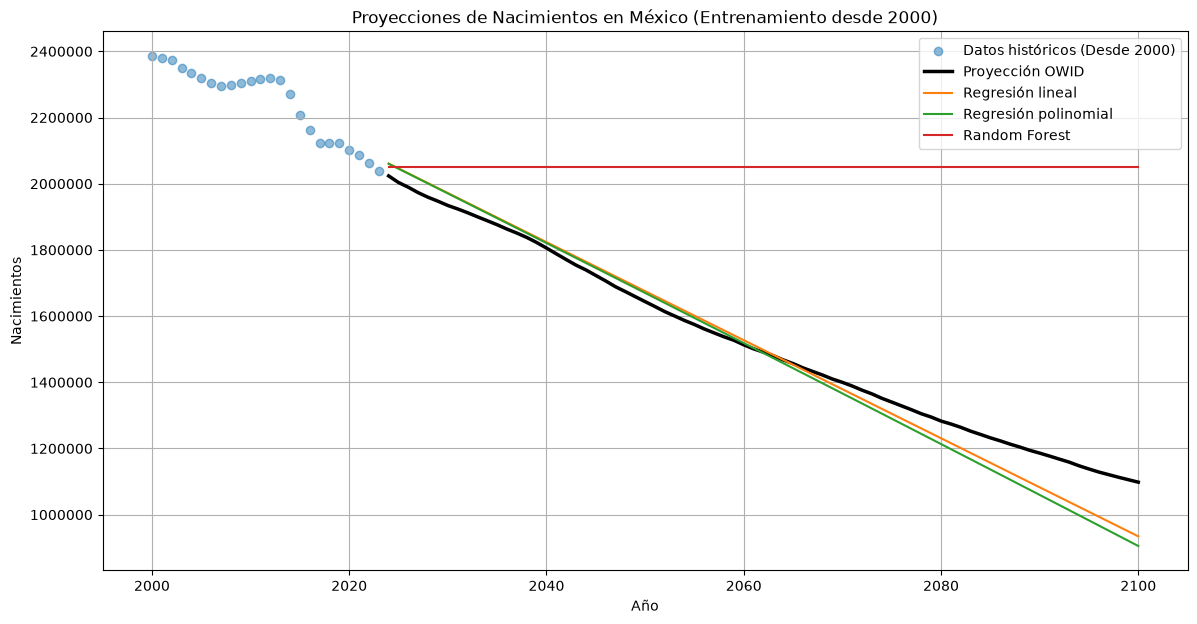

In [64]:
proyectar_y_graficar(df_mexico, anio_inicio=2000, variable_objetivo="births")

### observaciónes

*Tendencia simplificada (Puntos azules): Al descartar los datos del siglo XX, los algoritmos solo procesan una caída reciente que es casi recta y constante.*

*Ajuste de alta precisión (Naranja y Verde): La Regresión Lineal y la Polinomial se alinean de forma sobresaliente con la proyección de OWID durante las primeras décadas, desviándose solo al final del siglo al proyectar una caída un poco más agresiva.*

*Bloqueo del Random Forest (Rojo): Mantiene su falla estructural para series de tiempo; proyecta una línea horizontal infinita basada de manera exclusiva en el último dato de 2023.*

*Proyección OWID (Negro): Valida la fuerte tendencia a la baja que aprendieron las regresiones, pero aplica una estabilización más realista cerca de 1.1 millones de nacimientos hacia el 2100.*

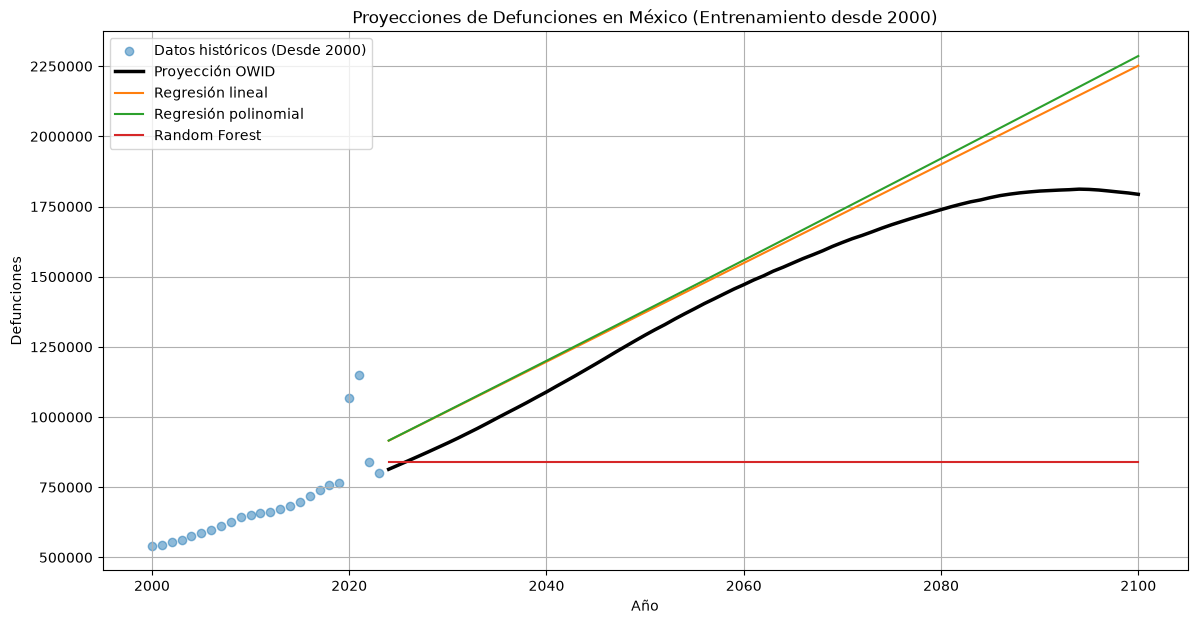

In [65]:
proyectar_y_graficar(df_mexico, anio_inicio=2000, variable_objetivo="deaths")

### observaciónes

*Sesgo por tendencia reciente (Puntos azules): El aumento continuo desde principios de siglo y el pico anómalo de mortalidad en 2020 provocan que los algoritmos asimilen una trayectoria de ascenso agresivo.*

*Proyección descontrolada (Naranja y Verde): La Regresión Lineal y la Polinomial se disparan hacia arriba sin control, pronosticando más de 2.25 millones de muertes para 2100 y superando por mucho las estimaciones lógicas.*

*Falla de extrapolación (Rojo): El Random Forest vuelve a trazar una línea completamente horizontal anclada en el último dato de 2023, siendo inútil para predecir el impacto futuro del envejecimiento poblacional.*

*Curva demográfica real (Negro): La proyección experta de OWID demuestra que las defunciones tienen un tope natural en relación con la población total, trazando una curva que llega a su punto máximo cerca de 2090 y luego se estabiliza.*